
=== frame_dur = 0.048s ===
longest template ~0.73s -> clip length 1.732s
vote_frac=0.5  worst-type F1=0.842
  st: thr=0.1525 | pair-level P=0.86 R=0.95 F1=0.90 | after voting (per clip) P=0.91 R=1.00 F1=0.95
  mt: thr=0.1501 | pair-level P=0.81 R=0.61 F1=0.70 | after voting (per clip) P=0.89 R=0.80 F1=0.84
  bt: thr=0.1526 | pair-level P=0.91 R=0.67 F1=0.77 | after voting (per clip) P=1.00 R=0.80 F1=0.89

=== frame_dur = 0.064s ===
longest template ~0.74s -> clip length 1.736s
vote_frac=0.3  worst-type F1=0.842
  st: thr=0.1628 | pair-level P=0.86 R=0.92 F1=0.89 | after voting (per clip) P=0.83 R=1.00 F1=0.91
  mt: thr=0.1709 | pair-level P=0.74 R=0.71 F1=0.72 | after voting (per clip) P=0.91 R=1.00 F1=0.95
  bt: thr=0.1563 | pair-level P=0.93 R=0.65 F1=0.76 | after voting (per clip) P=0.89 R=0.80 F1=0.84

=== frame_dur = 0.096s ===
longest template ~0.74s -> clip length 1.744s
vote_frac=0.5  worst-type F1=0.842
  st: thr=0.1702 | pair-level P=0.91 R=0.84 F1=0.88 | after voting (per c

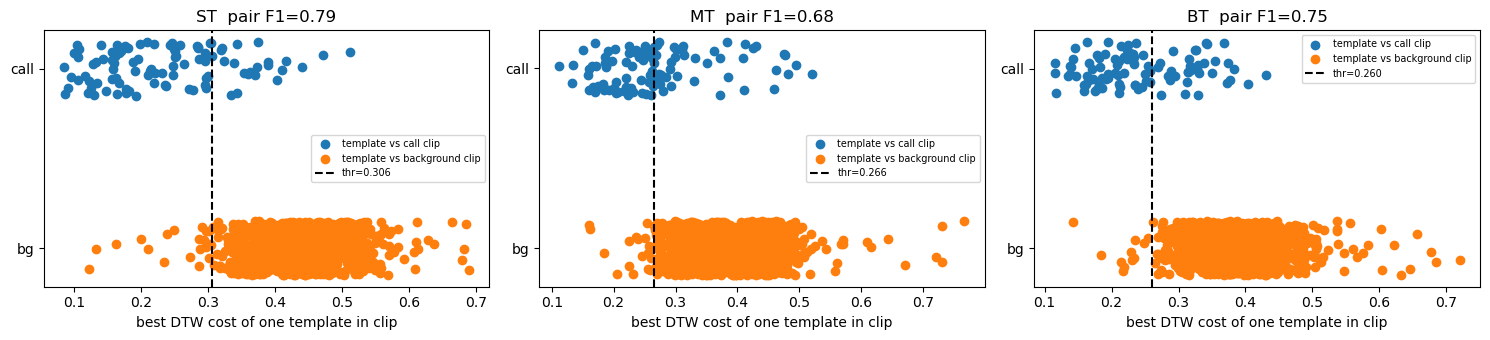

Saved config to C:\Users\HP\Desktop\Skripsie data\Results\stream_config_stft_10.json


{'feat_method': 'stft',
 'frame_len': 0.512,
 'f_min': 0.0,
 'fs_new': 1000,
 'thresholds': {'st': 0.3064076453447342,
  'mt': 0.2659789174795151,
  'bt': 0.2598496675491333},
 'vote_frac': 0.4,
 'n_temps': 10,
 'min_sep_s': 0.5,
 'calibration_worst_type_f1': 0.9,
 'per_type': {'st': {'threshold': 0.3064076453447342,
   'f1': 0.9,
   'p': 0.9,
   'r': 0.9,
   'pair_f1': 0.7939698492462312,
   'pair_p': 0.797979797979798,
   'pair_r': 0.79,
   'pos': [0.4158170521259308,
    0.12267348915338516,
    0.34351861476898193,
    0.13026395440101624,
    0.1564904749393463,
    0.2847067713737488,
    0.15962328016757965,
    0.1616562008857727,
    0.24803724884986877,
    0.1405886858701706,
    0.5124656558036804,
    0.19169065356254578,
    0.3189445436000824,
    0.08651132881641388,
    0.3058367967605591,
    0.23722848296165466,
    0.10801251977682114,
    0.08486056327819824,
    0.10577791184186935,
    0.2206304669380188,
    0.16409362852573395,
    0.2720988988876343,
    0.156

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from calibration import load_entries, load_template_features_fixed_length
from feature import make_stft_extractor, load_features_from_json
from stream_detect import TYPES, frame_geometry, calibrate_from_clips, save_stream_config

# ---------------- editable variables ----------------
feat_method = "stft"
n_calib = 10               # verified calls per call type (day-26 file)
n_bg = 100                 # verified background clips (None = use every entry in the file)
n_temps = 10
fs_new = 1000
f_min = 0.0               # Hz: high-pass + drop STFT bins below this (0.0 = old behaviour)
min_sep_s = 0.5            # used at deployment: detections closer than this count as one call

# Each calibration clip is cut to the same length: longest template + slack on BOTH sides.
# The slack is the room the template has to slide around in. It is NOT tuned by F1.
slack_s = 0.5

feat_frame_lengths = [0.048, 0.064, 0.096, 0.128, 0.192, 0.256, 0.384, 0.512]
vote_fracs = [0.2, 0.4, 0.6, 0.8, 1.0] if n_temps == 5 else [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# ---------------- paths ----------------
RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")
DATA_26 = Path(r"C:\Users\HP\Desktop\Skripsie data\26")
RESULTS_26 = DATA_26 / "template_selections"
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

bg_file = "Bground_CALIB_26_20230426_075505_background.json"
calib_files = {
    "st": "ST_CALIB_26_20230426_075505_single_tone_templates.json",
    "mt": "MT_CALIB_26_20230426_075505_multi_tone_templates.json",
    "bt": "BT_CALIB_26_20230426_075505_burst_tonal_templates.json",
}
template_files = {
    "st": "20230429_Templates_20230429_102841_single_tone_templates.json",
    "mt": "20230429_Templates_20230429_102841_multi_tone_templates.json",
    "bt": "20230429_Templates_20230429_102841_burst_tonal_templates.json",
}

# verified clip definitions (start/end times only; audio is read per frame length below)
bg_entries = load_entries(RESULTS_26 / bg_file, n_bg)
call_entries = {t: load_entries(RESULTS_26 / calib_files[t], n_calib) for t in TYPES}

# ---------------- run ----------------
all_results = {}
for frame_len in feat_frame_lengths:
    print(f"\n=== frame_dur = {frame_len}s ===")
    extractor = make_stft_extractor(frame_dur=frame_len, f_min=f_min)
    hop_s, _ = frame_geometry(extractor, fs_new)

    templates = {t: load_features_from_json(RESULTS_29 / template_files[t], extractor, n_temps, fs_new)
                 for t in TYPES}

    max_tmpl_s = max(f.shape[1] for fl in templates.values() for f in fl) * hop_s
    search_len = round(max_tmpl_s + 2 * slack_s, 3)
    print(f"longest template ~{max_tmpl_s:.2f}s -> clip length {search_len}s")

    call_clips = {t: [load_template_features_fixed_length(e, extractor, search_len, fs_new)
                      for e in call_entries[t]] for t in TYPES}
    bg_clips = [load_template_features_fixed_length(e, extractor, search_len, fs_new) for e in bg_entries]

    res = calibrate_from_clips(templates, call_clips, bg_clips, vote_fracs)
    res["search_len_s"] = search_len
    all_results[frame_len] = res
    print(f"vote_frac={res['vote_frac']}  worst-type F1={res['score']:.3f}")
    for t in TYPES:
        d = res["per_type"][t]
        print(f"  {t}: thr={d['threshold']:.4f} | pair-level P={d['pair_p']:.2f} R={d['pair_r']:.2f} F1={d['pair_f1']:.2f}"
              f" | after voting (per clip) P={d['p']:.2f} R={d['r']:.2f} F1={d['f1']:.2f}")

# best frame length: best worst-case F1 (ties -> longer frame, as before)
best_frame_len = max(all_results, key=lambda f: (all_results[f]["score"], f))
best = all_results[best_frame_len]
print(f"\nChosen frame length: {best_frame_len}s   vote_frac: {best['vote_frac']}   F1: {best['score']:.3f}")
print("Thresholds:", best["thresholds"])

# sanity plot: every template-vs-clip cost for the chosen setting (blue = verified calls, orange = verified background)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
rng = np.random.default_rng(0)
for ax, t in zip(axes, TYPES):
    d = best["per_type"][t]
    ax.scatter(d["pos"], 1 + rng.uniform(-.15, .15, len(d["pos"])), color="tab:blue", label="template vs call clip")
    ax.scatter(d["neg"], rng.uniform(-.15, .15, len(d["neg"])), color="tab:orange", label="template vs background clip")
    ax.axvline(d["threshold"], color="k", linestyle="--", label=f"thr={d['threshold']:.3f}")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["bg", "call"])
    ax.set_title(f"{t.upper()}  pair F1={d['pair_f1']:.2f}")
    ax.set_xlabel("best DTW cost of one template in clip")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

save_stream_config(
    RESULTS / f"stream_config_{feat_method}_{n_temps}.json",
    feat_method=feat_method, frame_len=best_frame_len, f_min=f_min, fs_new=fs_new,
    thresholds=best["thresholds"], vote_frac=best["vote_frac"], n_temps=n_temps,
    n_calib=n_calib, search_len_s=best["search_len_s"], min_sep_s=min_sep_s,
    score=best["score"], per_type=best["per_type"], template_files=template_files,
)